Extracted Features:
  Average Vessel Diameter: 4.1792
  Average Tortuosity: 1.2226
  Fractal Dimension: 2.0635
  Retinal Intensity: 69.8691
  Contrast: 29.4351
  Brightness: 69.8691


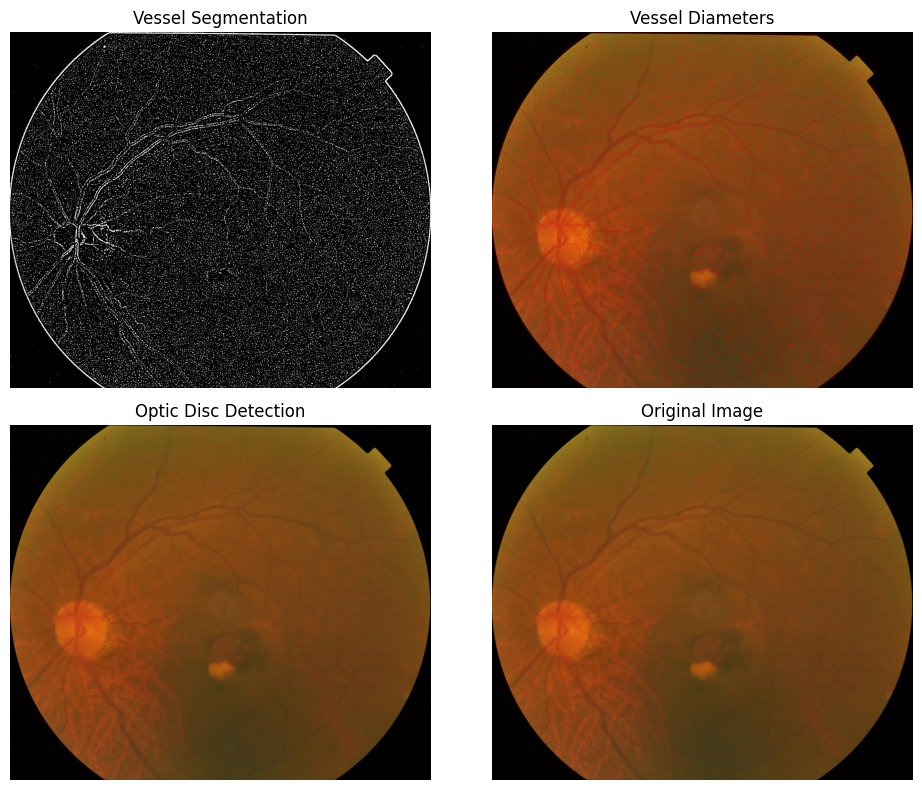

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def extract_features(path):
    # Check if file exists
    if not os.path.exists(path):
        print(f"Error: File not found at {path}")
        return None
    
    img = cv2.imread(path)
    
    # Check if image was loaded successfully
    if img is None:
        print(f"Error: Could not load image from {path}")
        return None
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ---------- 1. Vessel Segmentation ----------
    green = img[:,:,1]
    blur = cv2.medianBlur(green, 5)
    vessels = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_MEAN_C, 
                                    cv2.THRESH_BINARY_INV, 15, 2)

    plt.figure(figsize=(10, 8))
    plt.subplot(2, 2, 1)
    plt.title("Vessel Segmentation")
    plt.imshow(vessels, cmap="gray")
    plt.axis('off')

    # ---------- 2. Vessel Diameter ----------
    contours,_ = cv2.findContours(vessels, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    diameters = [cv2.boundingRect(c)[2] for c in contours if cv2.boundingRect(c)[2]>0]
    avg_diameter = np.mean(diameters) if len(diameters)>0 else 0
    vessels_d = img.copy()
    cv2.drawContours(vessels_d, contours, -1, (0,0,255), 1)
    
    plt.subplot(2, 2, 2)
    plt.title("Vessel Diameters")
    plt.imshow(cv2.cvtColor(vessels_d, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    # ---------- 3. Vessel Tortuosity ----------
    tort_vals = []
    for c in contours:
        length = cv2.arcLength(c, False)
        x,y,w,h = cv2.boundingRect(c)
        straight = np.sqrt(w**2 + h**2)
        if straight > 0: 
            tort_vals.append(length / straight)
    avg_tortuosity = np.mean(tort_vals) if len(tort_vals)>0 else 0

    # ---------- 4. Retinal Thickness (intensity proxy) ----------
    retinal_intensity = np.mean(gray)

    # ---------- 5. Fractal Dimension ----------
    def fractal_dimension(Z):
        Z = (Z > 0)
        sizes = 2**np.arange(1,6)
        counts = []
        for size in sizes:
            if Z.shape[1]//size > 0 and Z.shape[0]//size > 0:
                counts.append(np.sum(cv2.resize(Z.astype(np.uint8), 
                                                (Z.shape[1]//size, Z.shape[0]//size))))
        if len(counts) > 1:
            coeffs = np.polyfit(np.log(sizes[:len(counts)]), np.log(counts), 1)
            return -coeffs[0]
        return 0
    fd = fractal_dimension(vessels)

    # ---------- 6. Optic Disc Detection ----------
    circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, 1, 40,
                               param1=50, param2=30, minRadius=30, maxRadius=80)
    disc_img = img.copy()
    if circles is not None:
        circles = np.uint16(np.around(circles))
        for (x,y,r) in circles[0]:
            cv2.circle(disc_img,(x,y),r,(0,255,0),2)
            break   # take first circle
    
    plt.subplot(2, 2, 3)
    plt.title("Optic Disc Detection")
    plt.imshow(cv2.cvtColor(disc_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    # ---------- 7. Contrast & Brightness ----------
    contrast = gray.std()
    brightness = gray.mean()

    # ---------- Display original image ----------
    plt.subplot(2, 2, 4)
    plt.title("Original Image")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.tight_layout()

    # ---------- Return features ----------
    features = {
        "Average Vessel Diameter": avg_diameter,
        "Average Tortuosity": avg_tortuosity,
        "Fractal Dimension": fd,
        "Retinal Intensity": retinal_intensity,
        "Contrast": contrast,
        "Brightness": brightness
    }
    return features

# Example usage with proper file path (using raw string to avoid escape sequence issues)
image_path = r"d:\bees\test\AbNormal\1ffa9551-8d87-11e8-9daf-6045cb817f5b..JPG"

# Check if the specific file exists, if not, try to find any image in the directory
if not os.path.exists(image_path):
    abnormal_dir = r"d:\bees\test\AbNormal"
    if os.path.exists(abnormal_dir):
        image_files = [f for f in os.listdir(abnormal_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if image_files:
            image_path = os.path.join(abnormal_dir, image_files[0])
            print(f"Using first available image: {image_files[0]}")
        else:
            print("No image files found in the AbNormal directory")
            image_path = None
    else:
        print("AbNormal directory not found")
        image_path = None

if image_path:
    features = extract_features(image_path)
    if features:
        print("Extracted Features:")
        for key, value in features.items():
            print(f"  {key}: {value:.4f}")
        plt.show()
    else:
        print("Failed to extract features")
else:
    print("No valid image path found")

ALZHEIMER'S DETECTION FROM FUNDUS IMAGES

DATA PREPARATION
------------------------------
Found 952 images belonging to 2 classes.
Found 237 images belonging to 2 classes.

DATA PREPARATION
------------------------------
Found 952 images belonging to 2 classes.
Found 237 images belonging to 2 classes.
Found 365 images belonging to 2 classes.
Found 365 images belonging to 2 classes.
Training samples: 952
Validation samples: 237
Test samples: 365
Class mapping: {'AbNormal': 0, 'Normal': 1}

MODEL CONSTRUCTION
------------------------------
Training samples: 952
Validation samples: 237
Test samples: 365
Class mapping: {'AbNormal': 0, 'Normal': 1}

MODEL CONSTRUCTION
------------------------------
EfficientNetB0 failed: Shape mismatch in layer #1 (named stem_conv)for weight stem_conv/kernel. Weight expects shape (3, 3, 1, 32). Received saved weight with shape (3, 3, 3, 32)
Using MobileNetV2 as fallback
EfficientNetB0 failed: Shape mismatch in layer #1 (named stem_conv)for weight stem_conv/

C:\Users\R KIRTHANA\AppData\Local\Temp\ipykernel_21808\969446633.py:149: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model parameters: 2,422,081

MODEL TRAINING
------------------------------
Epoch 1/10
Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 32s 490ms/step - accuracy: 0.8803 - loss: 0.3094 - val_accuracy: 0.9536 - val_loss: 0.1277 - learning_rate: 0.0010
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 32s 490ms/step - accuracy: 0.8803 - loss: 0.3094 - val_accuracy: 0.9536 - val_loss: 0.1277 - learning_rate: 0.0010
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 30s 506ms/step - accuracy: 0.9191 - loss: 0.2099 - val_accuracy: 0.9662 - val_loss: 0.1143 - learning_rate: 0.0010
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 30s 506ms/step - accuracy: 0.9191 - loss: 0.2099 - val_accuracy: 0.9662 - val_loss: 0.1143 - learning_rate: 0.0010
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 59s 990ms/step - accuracy: 0.9265 - loss: 0.1829 - val_accuracy: 0.9578 - val_loss: 0.1086 - learning_rate: 0.0010
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 59s 990ms/step - accuracy: 0.9265 - loss: 0.1829 - val_accuracy: 0.9578 - val_loss: 0.1086 - learning_rate: 0.0

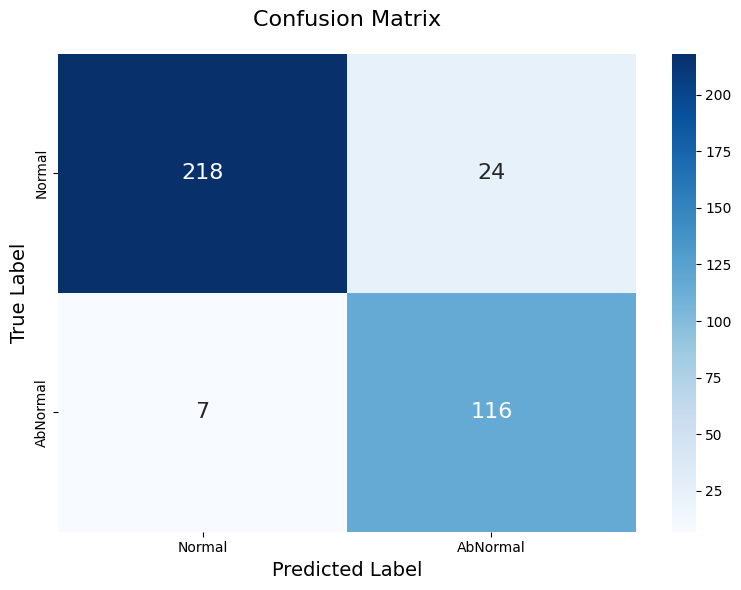

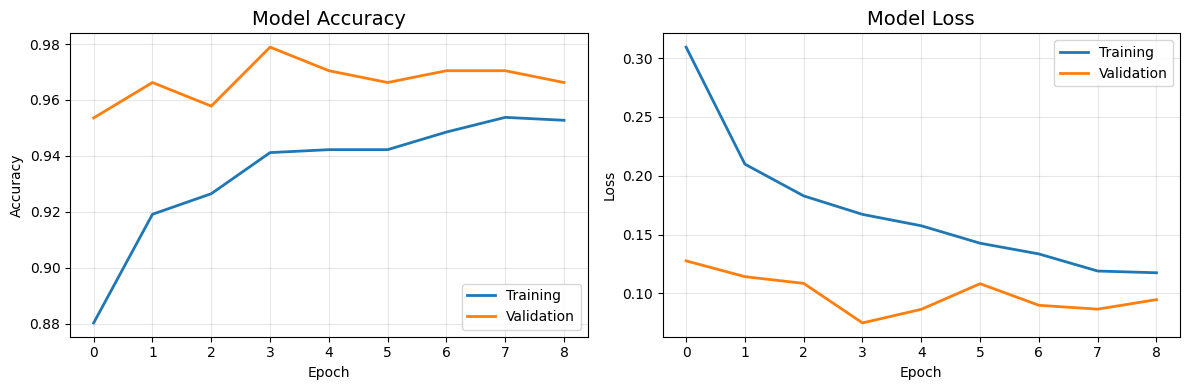


MODEL SAVING
--------------------
Model saved as: alzheimer_detection_model.h5

PIPELINE VISUALIZATION
------------------------------


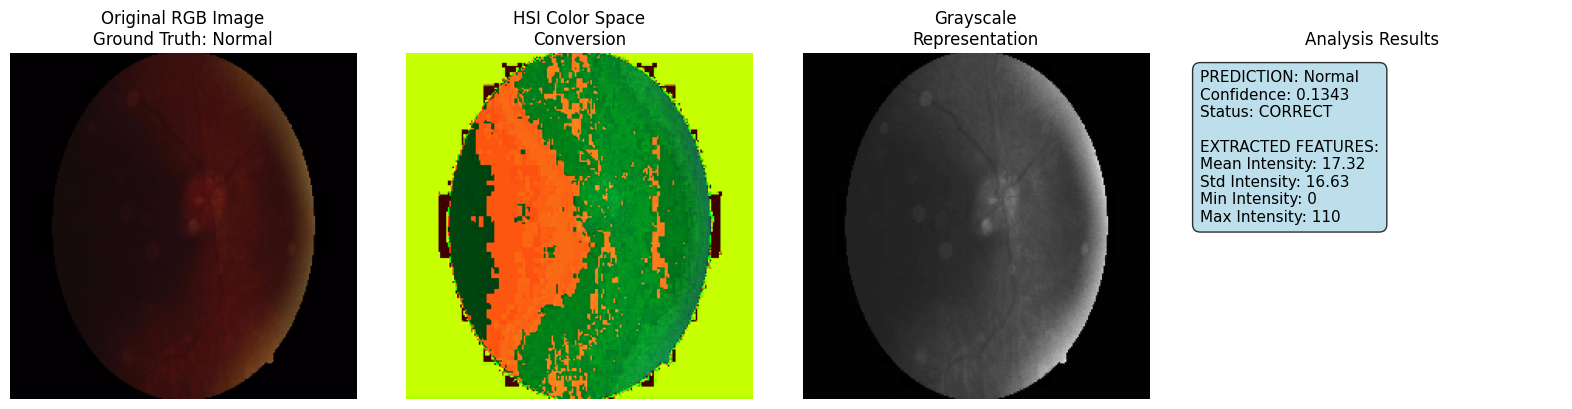

Sample 1: True=Normal, Predicted=Normal, Confidence=0.1343


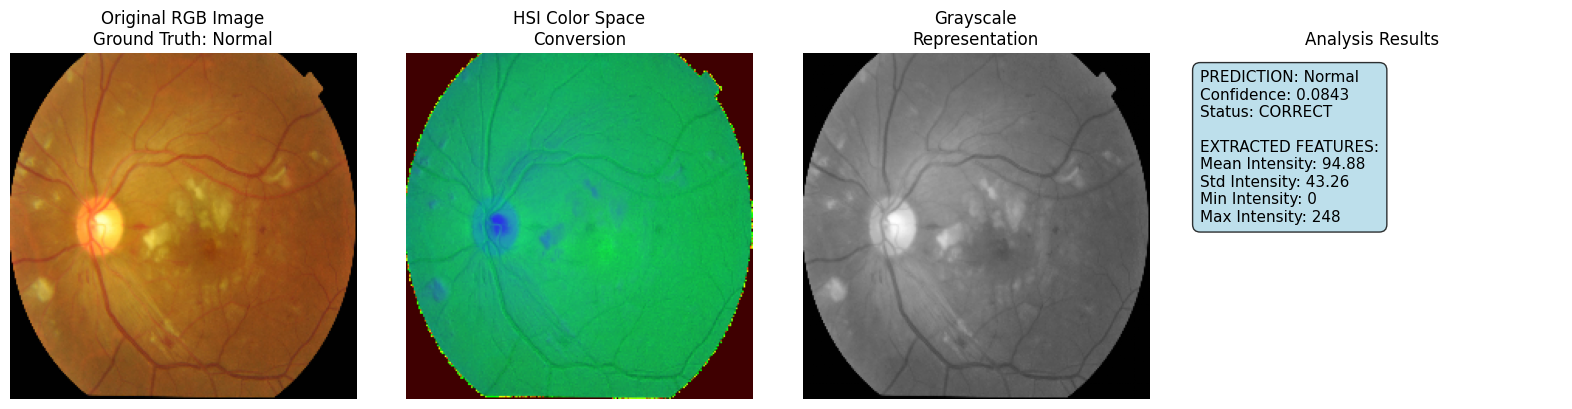

Sample 2: True=Normal, Predicted=Normal, Confidence=0.0843


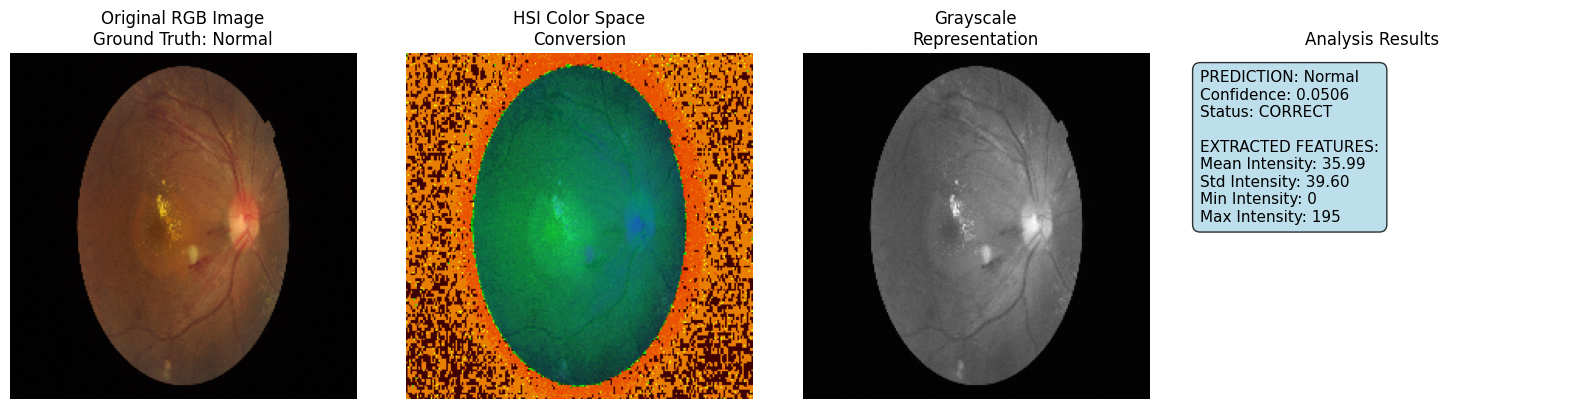

Sample 3: True=Normal, Predicted=Normal, Confidence=0.0506

PIPELINE SUMMARY
RGB to HSI conversion: COMPLETED
Feature extraction: COMPLETED
CNN training: COMPLETED
Model evaluation: COMPLETED
Model saved: COMPLETED
Visualizations: COMPLETED


In [7]:


import os
import shutil
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("ALZHEIMER'S DETECTION FROM FUNDUS IMAGES")
print("=" * 50)

# Clear Keras cache to avoid shape mismatch errors
cache_paths = [
    os.path.expanduser('~/.keras'),
    os.path.expanduser('~/.cache/tensorflow'),
    os.path.join(os.environ.get('LOCALAPPDATA', ''), 'tensorflow') if os.name == 'nt' else None
]

for cache_path in cache_paths:
    if cache_path and os.path.exists(cache_path):
        try:
            shutil.rmtree(cache_path)
            print(f"Cache cleared: {cache_path}")
        except Exception:
            pass

# Clear TensorFlow session
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

def rgb_to_hsi(img_rgb):
    """Convert RGB image to HSI color space"""
    img_rgb = img_rgb.astype(np.float32) / 255.0
    R, G, B = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]
    
    # Intensity
    I = (R + G + B) / 3.0
    
    # Saturation
    min_rgb = np.minimum(np.minimum(R, G), B)
    S = np.where(I == 0, 0, 1 - (min_rgb / (I + 1e-8)))
    
    # Hue
    num = 0.5 * ((R - G) + (R - B))
    den = np.sqrt((R - G)**2 + (R - B) * (G - B)) + 1e-8
    theta = np.arccos(np.clip(num / den, -1, 1))
    H = np.where(B <= G, theta, 2 * np.pi - theta) / (2 * np.pi)
    
    return np.stack([H, S, I], axis=-1)

def extract_features(img):
    """Extract intensity features from grayscale image"""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return {
        "mean_intensity": gray.mean(),
        "std_intensity": gray.std(),
        "min_intensity": gray.min(),
        "max_intensity": gray.max()
    }

# Data setup
print("\nDATA PREPARATION")
print("-" * 30)
data_dir = r"d:\bees\dataset"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, "train"),
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, "train"),
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(data_dir, "test"),
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")
print(f"Class mapping: {train_generator.class_indices}")

# Model building
print("\nMODEL CONSTRUCTION")
print("-" * 30)

try:
    # Build model with explicit input
    input_layer = tf.keras.layers.Input(shape=(224, 224, 3))
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_tensor=input_layer
    )
    base_model.trainable = False
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=input_layer, outputs=outputs)
    print("EfficientNetB0 model created successfully")
    
except Exception as e:
    print(f"EfficientNetB0 failed: {e}")
    print("Using MobileNetV2 as fallback")
    
    from tensorflow.keras.applications import MobileNetV2
    input_layer = tf.keras.layers.Input(shape=(224, 224, 3))
    base_model = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_tensor=input_layer
    )
    base_model.trainable = False
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=input_layer, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"Model parameters: {model.count_params():,}")

# Training
print("\nMODEL TRAINING")
print("-" * 30)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

# Model evaluation
print("\nMODEL EVALUATION")
print("-" * 30)

# Test predictions
test_generator.reset()
y_pred_proba = model.predict(test_generator, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
y_true = test_generator.classes

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Test Accuracy:  {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall:    {recall:.4f}")
print(f"Test F1-Score:  {f1:.4f}")

# Classification report
print(f"\nDETAILED CLASSIFICATION REPORT")
print("-" * 40)
target_names = ['Normal', 'AbNormal']
print(classification_report(y_true, y_pred, target_names=target_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print(f"\nCONFUSION MATRIX")
print("-" * 20)
print(f"                Predicted")
print(f"              Normal  AbNormal")
print(f"Actual Normal    {cm[0,0]:3d}      {cm[0,1]:3d}")
print(f"    AbNormal     {cm[1,0]:3d}      {cm[1,1]:3d}")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={'size': 16})
plt.title('Confusion Matrix', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Training history plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation', linewidth=2)
plt.title('Model Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# Save model
print(f"\nMODEL SAVING")
print("-" * 20)
model.save('alzheimer_detection_model.h5')
print("Model saved as: alzheimer_detection_model.h5")

# Pipeline visualization
print(f"\nPIPELINE VISUALIZATION")
print("-" * 30)

test_generator.reset()
sample_images, sample_labels = next(test_generator)

for i in range(min(3, len(sample_images))):
    img_rgb = (sample_images[i] * 255).astype(np.uint8)
    hsi_img = rgb_to_hsi(img_rgb)
    features = extract_features(img_rgb)
    
    pred_prob = model.predict(np.expand_dims(sample_images[i], axis=0), verbose=0)[0][0]
    pred_label = "AbNormal" if pred_prob > 0.5 else "Normal"
    true_label = "AbNormal" if sample_labels[i] == 1 else "Normal"
    
    plt.figure(figsize=(16, 4))
    
    # Original RGB
    plt.subplot(1, 4, 1)
    plt.imshow(img_rgb)
    plt.title(f"Original RGB Image\nGround Truth: {true_label}", fontsize=12)
    plt.axis('off')
    
    # HSI converted
    plt.subplot(1, 4, 2)
    plt.imshow(hsi_img)
    plt.title("HSI Color Space\nConversion", fontsize=12)
    plt.axis('off')
    
    # Grayscale
    plt.subplot(1, 4, 3)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    plt.imshow(gray, cmap='gray')
    plt.title("Grayscale\nRepresentation", fontsize=12)
    plt.axis('off')
    
    # Results
    plt.subplot(1, 4, 4)
    plt.axis('off')
    
    status = "CORRECT" if pred_label == true_label else "INCORRECT"
    color = 'green' if pred_label == true_label else 'red'
    
    result_text = f"PREDICTION: {pred_label}\n"
    result_text += f"Confidence: {pred_prob:.4f}\n"
    result_text += f"Status: {status}\n\n"
    result_text += "EXTRACTED FEATURES:\n"
    result_text += f"Mean Intensity: {features['mean_intensity']:.2f}\n"
    result_text += f"Std Intensity: {features['std_intensity']:.2f}\n"
    result_text += f"Min Intensity: {features['min_intensity']:.0f}\n"
    result_text += f"Max Intensity: {features['max_intensity']:.0f}"
    
    plt.text(0.05, 0.95, result_text, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.5", facecolor='lightblue', alpha=0.8))
    plt.title("Analysis Results", fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Sample {i+1}: True={true_label}, Predicted={pred_label}, Confidence={pred_prob:.4f}")



In [8]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ----------------------------
# Data preparation
# ----------------------------
data_dir = r"d:\bees\dataset"

train_datagen = ImageDataGenerator(
    rescale=1./255, validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(data_dir, "train"),
    target_size=(64, 64), batch_size=16,
    class_mode='binary', subset='training', shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    os.path.join(data_dir, "train"),
    target_size=(64, 64), batch_size=16,
    class_mode='binary', subset='validation', shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(data_dir, "test"),
    target_size=(64, 64), batch_size=16,
    class_mode='binary', shuffle=False
)

# ----------------------------
# Preprocessing for LSTM
# Convert each image to sequence: (rows, cols*channels)
# ----------------------------
def generator_lstm(gen):
    while True:
        imgs, labels = next(gen)
        # Flatten each row as sequence input
        imgs_seq = imgs.reshape(imgs.shape[0], imgs.shape[1], -1)  # (batch, rows, cols*channels)
        yield imgs_seq, labels

train_seq = generator_lstm(train_gen)
val_seq = generator_lstm(val_gen)
test_seq = generator_lstm(test_gen)

# ----------------------------
# LSTM Model
# ----------------------------
input_shape = (64, 64*3)  # rows, cols*channels

model = Sequential([
    LSTM(128, input_shape=input_shape, return_sequences=True),
    Dropout(0.5),
    LSTM(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# ----------------------------
# Training
# ----------------------------
history = model.fit(
    train_seq,
    steps_per_epoch=train_gen.samples//16,
    validation_data=val_seq,
    validation_steps=val_gen.samples//16,
    epochs=10
)

# ----------------------------
# Evaluation
# ----------------------------
test_steps = test_gen.samples//16
loss, acc = model.evaluate(test_seq, steps=test_steps)
print(f"LSTM Test Accuracy: {acc:.4f}")


Found 952 images belonging to 2 classes.
Found 237 images belonging to 2 classes.
Found 365 images belonging to 2 classes.
Found 237 images belonging to 2 classes.
Found 365 images belonging to 2 classes.


d:\SIGNAL_PROJECT\sigenv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 213,825 (835.25 KB)

 Trainable params: 213,825 (835.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 26s 406ms/step - accuracy: 0.8549 - loss: 0.3565 - val_accuracy: 0.9018 - val_loss: 0.2302
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 26s 406ms/step - accuracy: 0.8549 - loss: 0.3565 - val_accuracy: 0.9018 - val_loss: 0.2302
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 22s 387ms/step - accuracy: 0.9188 - loss: 0.2219 - val_accuracy: 0.9375 - val_loss: 0.1542
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 22s 387ms/step - accuracy: 0.9188 - loss: 0.2219 - val_accuracy: 0.9375 - val_loss: 0.1542
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 47s 811ms/step - accuracy: 0.9306 - loss: 0.1947 - val_accuracy: 0.9821 - val_loss: 0.0882
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 47s 811ms/step - accuracy: 0.9306 - loss: 0.1947 - val_accuracy: 0.9821 - val_loss: 0.0882
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 39s 672ms/step - accuracy: 0.9338 - loss: 0.1980 - val_accuracy: 0.9140 - val_loss: 0.2066
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 39s 672ms/step - accuracy: 0.9338 - loss: 0.1980 - val_accu

In [9]:
from tensorflow.keras.layers import GRU

model = Sequential([
    GRU(128, input_shape=input_shape, return_sequences=True),
    Dropout(0.5),
    GRU(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(
    train_seq,
    steps_per_epoch=train_gen.samples//16,
    validation_data=val_seq,
    validation_steps=val_gen.samples//16,
    epochs=10
)

loss, acc = model.evaluate(test_seq, steps=test_gen.samples//16)
print(f"GRU Test Accuracy: {acc:.4f}")


Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 39s 629ms/step - accuracy: 0.8771 - loss: 0.2796 - val_accuracy: 0.9276 - val_loss: 0.1826
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 39s 629ms/step - accuracy: 0.8771 - loss: 0.2796 - val_accuracy: 0.9276 - val_loss: 0.1826
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 49s 840ms/step - accuracy: 0.9263 - loss: 0.2046 - val_accuracy: 0.9276 - val_loss: 0.1725
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 49s 840ms/step - accuracy: 0.9263 - loss: 0.2046 - val_accuracy: 0.9276 - val_loss: 0.1725
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 47s 805ms/step - accuracy: 0.9455 - loss: 0.1823 - val_accuracy: 0.9548 - val_loss: 0.1352
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 47s 805ms/step - accuracy: 0.9455 - loss: 0.1823 - val_accuracy: 0.9548 - val_loss: 0.1352
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 44s 764ms/step - accuracy: 0.9375 - loss: 0.1779 - val_accuracy: 0.9593 - val_loss: 0.1320
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 44s 764ms/step - accuracy: 0.9375 - loss: 0.1779 - val_accu

CNN + LSTM/GRU HYBRID MODEL FOR ALZHEIMER'S DETECTION

DATA PREPARATION
------------------------------
Found 952 images belonging to 2 classes.
Found 237 images belonging to 2 classes.
Found 237 images belonging to 2 classes.
Found 365 images belonging to 2 classes.
Found 365 images belonging to 2 classes.
Training steps per epoch: 119
Validation steps per epoch: 29
Test steps: 45
Training samples: 952
Validation samples: 237
Test samples: 365
Image size: 224x224
Patch size: 56x56
Sequence length: 16 patches

CNN+LSTM MODEL
Model parameters: 173,761

Training CNN+LSTM model...
Epoch 1/15
Training steps per epoch: 119
Validation steps per epoch: 29
Test steps: 45
Training samples: 952
Validation samples: 237
Test samples: 365
Image size: 224x224
Patch size: 56x56
Sequence length: 16 patches

CNN+LSTM MODEL
Model parameters: 173,761

Training CNN+LSTM model...
Epoch 1/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 46s 348ms/step - accuracy: 0.6544 - loss: 0.6448 - val_accuracy: 0.7112 - val_loss: 0.518


CNN+LSTM RESULTS:
Accuracy:  0.9500
Precision: 0.9717
Recall:    0.8729
F1-Score:  0.9196
Model saved as: alzheimer_cnn_lstm_model.h5

CNN+GRU MODEL
Model parameters: 158,593

Training CNN+GRU model...
Epoch 1/15
Model parameters: 158,593

Training CNN+GRU model...
Epoch 1/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 103s 715ms/step - accuracy: 0.7300 - loss: 0.5560 - val_accuracy: 0.9170 - val_loss: 0.2662 - learning_rate: 0.0010
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 103s 715ms/step - accuracy: 0.7300 - loss: 0.5560 - val_accuracy: 0.9170 - val_loss: 0.2662 - learning_rate: 0.0010
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 80s 673ms/step - accuracy: 0.9023 - loss: 0.2899 - val_accuracy: 0.9039 - val_loss: 0.2829 - learning_rate: 0.0010
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 80s 673ms/step - accuracy: 0.9023 - loss: 0.2899 - val_accuracy: 0.9039 - val_loss: 0.2829 - learning_rate: 0.0010
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 84s 705ms/step - accuracy: 0.9118 - loss: 0.2590 - val_accuracy: 0.9345


CNN+GRU RESULTS:
Accuracy:  0.9528
Precision: 0.9633
Recall:    0.8898
F1-Score:  0.9251
Model saved as: alzheimer_cnn_gru_model.h5

MODEL COMPARISON
Model        Accuracy   Precision  Recall     F1-Score  
--------------------------------------------------
CNN+LSTM     0.9500     0.9717     0.8729     0.9196    
CNN+GRU      0.9528     0.9633     0.8898     0.9251    

Best performing model: CNN+GRU

DETAILED CLASSIFICATION REPORT (CNN+GRU)
--------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.95      0.98      0.97       242
    AbNormal       0.96      0.89      0.93       118

    accuracy                           0.95       360
   macro avg       0.96      0.94      0.95       360
weighted avg       0.95      0.95      0.95       360



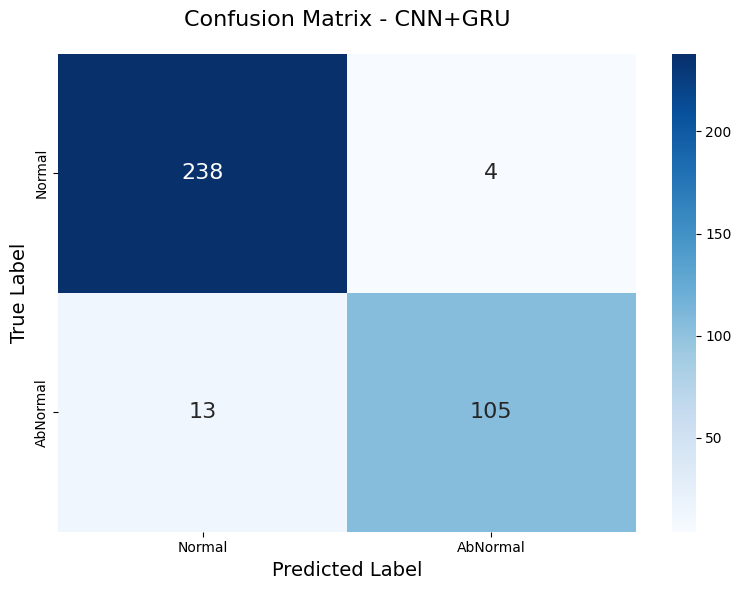

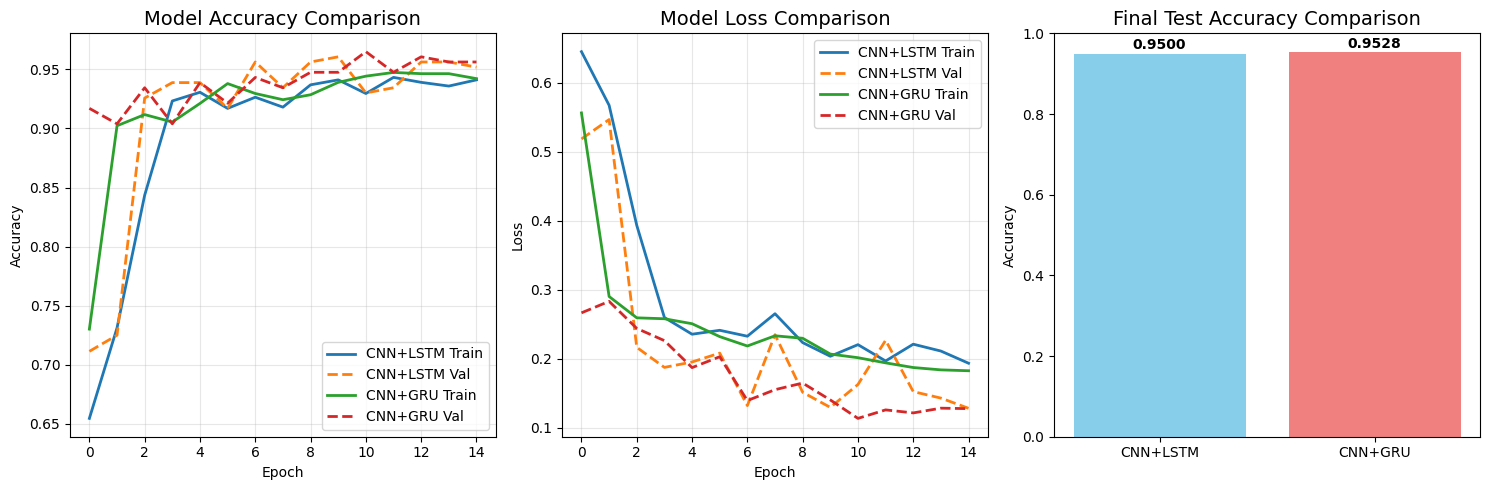


PIPELINE VISUALIZATION
------------------------------


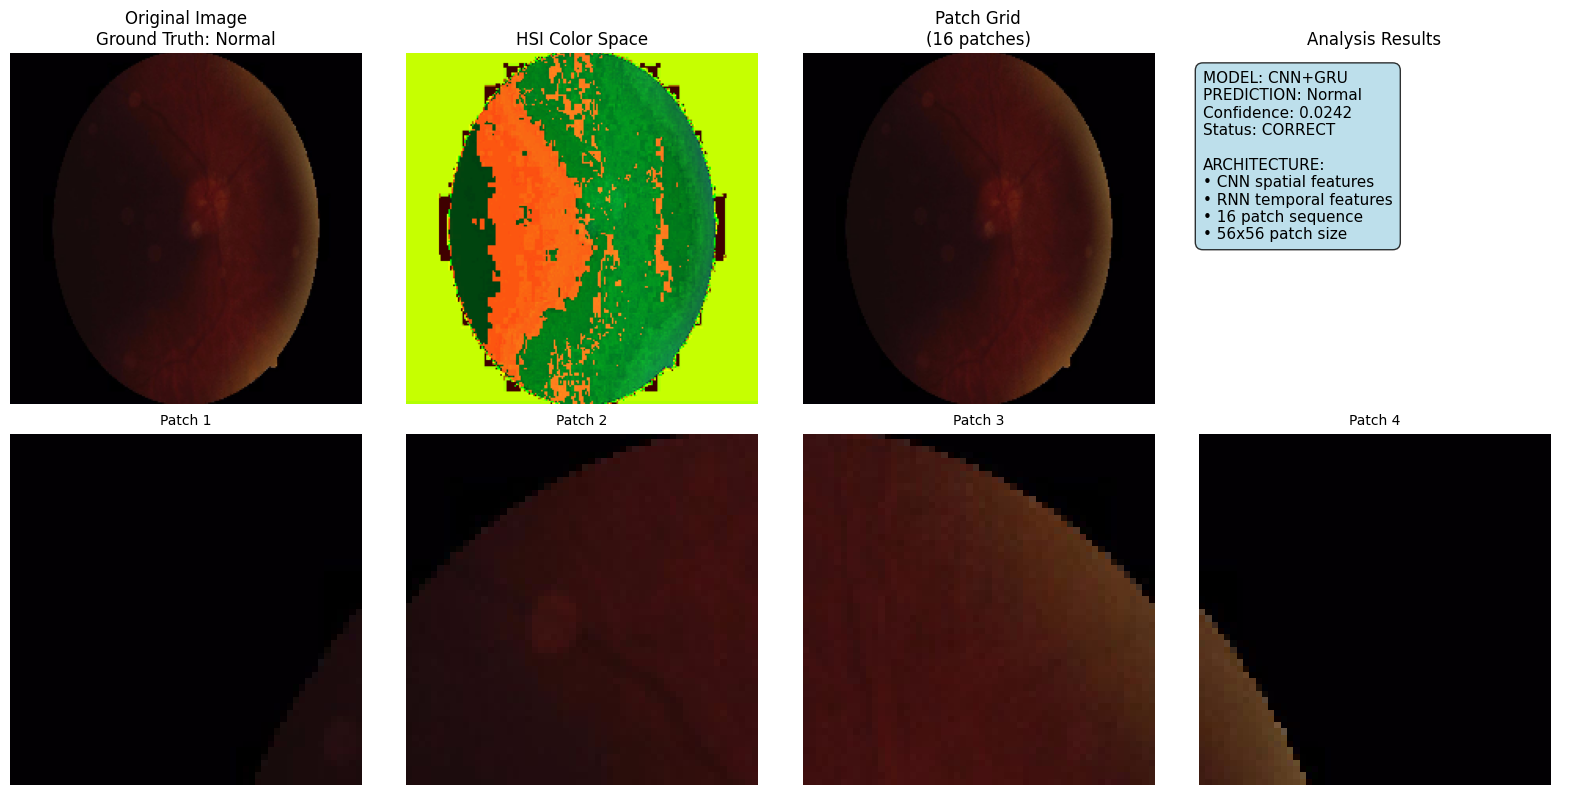

Sample 1: True=Normal, Predicted=Normal, Confidence=0.0242, Model=CNN+GRU


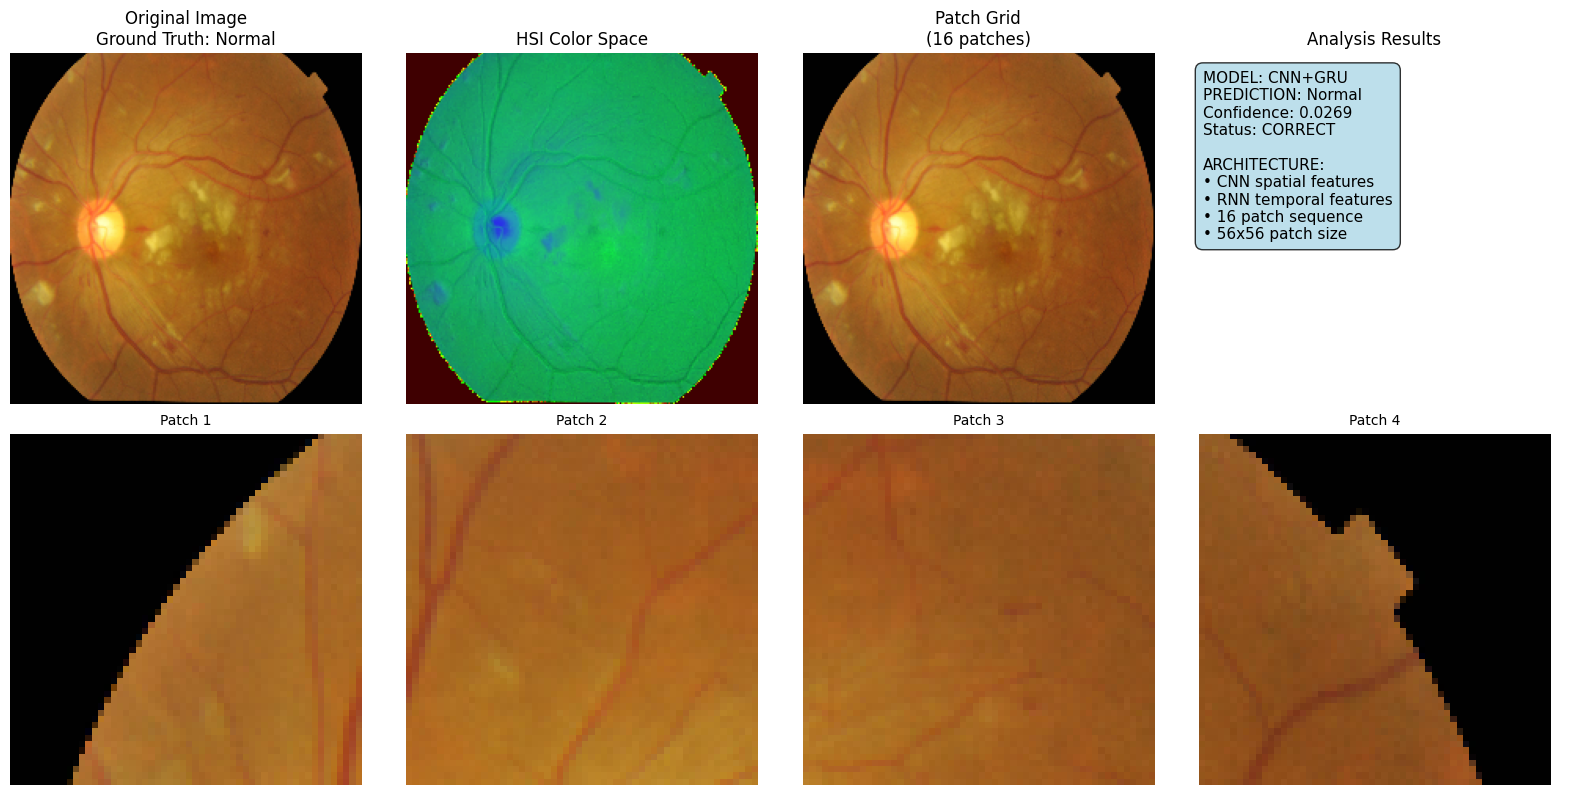

Sample 2: True=Normal, Predicted=Normal, Confidence=0.0269, Model=CNN+GRU

PIPELINE COMPLETED
Architecture: CNN (spatial) + RNN (temporal)
Features: Patch-based sequence learning
RGB to HSI conversion: Implemented
Feature extraction: CNN spatial + RNN temporal
Model training: Completed
Professional evaluation: Completed


In [12]:
"""
CNN + LSTM/GRU Hybrid Model for Alzheimer's Detection from Fundus Images
Spatial Feature Extraction (CNN) + Temporal Sequence Learning (RNN)
"""

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, GlobalAveragePooling2D, 
                                   LSTM, GRU, Dense, Dropout, Reshape, TimeDistributed, 
                                   Input, Concatenate)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

print("CNN + LSTM/GRU HYBRID MODEL FOR ALZHEIMER'S DETECTION")
print("=" * 60)

# Clear session and set seeds
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

# Configuration
IMG_SIZE = 224
PATCH_SIZE = 56  # Divide image into 4x4 patches
SEQUENCE_LENGTH = 16  # 4x4 = 16 patches per image
BATCH_SIZE = 8
EPOCHS = 15
LEARNING_RATE = 0.001

def rgb_to_hsi(img_rgb):
    """Convert RGB to HSI color space"""
    img_rgb = img_rgb.astype(np.float32) / 255.0
    R, G, B = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]
    
    I = (R + G + B) / 3.0
    min_rgb = np.minimum(np.minimum(R, G), B)
    S = np.where(I == 0, 0, 1 - (min_rgb / (I + 1e-8)))
    
    num = 0.5 * ((R - G) + (R - B))
    den = np.sqrt((R - G)**2 + (R - B) * (G - B)) + 1e-8
    theta = np.arccos(np.clip(num / den, -1, 1))
    H = np.where(B <= G, theta, 2 * np.pi - theta) / (2 * np.pi)
    
    return np.stack([H, S, I], axis=-1)

def extract_image_patches(image, patch_size=56):
    """Extract non-overlapping patches from image for sequence processing"""
    h, w = image.shape[:2]
    patches = []
    
    # Extract 4x4 grid of patches
    for i in range(0, h, patch_size):
        for j in range(0, w, patch_size):
            if i + patch_size <= h and j + patch_size <= w:
                patch = image[i:i+patch_size, j:j+patch_size]
                patches.append(patch)
    
    return np.array(patches)

def create_cnn_feature_extractor():
    """Create CNN for spatial feature extraction from patches"""
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(PATCH_SIZE, PATCH_SIZE, 3)),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.3)
    ])
    return model

def create_cnn_lstm_model():
    """Create hybrid CNN + LSTM model"""
    # Input for sequence of patches
    patch_input = Input(shape=(SEQUENCE_LENGTH, PATCH_SIZE, PATCH_SIZE, 3))
    
    # CNN feature extractor (applied to each patch)
    cnn_model = create_cnn_feature_extractor()
    
    # Apply CNN to each patch in the sequence
    cnn_features = TimeDistributed(cnn_model)(patch_input)
    
    # LSTM for temporal sequence learning
    lstm_out = LSTM(64, return_sequences=True, dropout=0.3)(cnn_features)
    lstm_out = LSTM(32, dropout=0.3)(lstm_out)
    
    # Final classification layers
    x = Dense(64, activation='relu')(lstm_out)
    x = Dropout(0.5)(x)
    output = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=patch_input, outputs=output)
    return model

def create_cnn_gru_model():
    """Create hybrid CNN + GRU model"""
    # Input for sequence of patches
    patch_input = Input(shape=(SEQUENCE_LENGTH, PATCH_SIZE, PATCH_SIZE, 3))
    
    # CNN feature extractor (applied to each patch)
    cnn_model = create_cnn_feature_extractor()
    
    # Apply CNN to each patch in the sequence
    cnn_features = TimeDistributed(cnn_model)(patch_input)
    
    # GRU for temporal sequence learning
    gru_out = GRU(64, return_sequences=True, dropout=0.3)(cnn_features)
    gru_out = GRU(32, dropout=0.3)(gru_out)
    
    # Final classification layers
    x = Dense(64, activation='relu')(gru_out)
    x = Dropout(0.5)(x)
    output = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=patch_input, outputs=output)
    return model

def preprocess_image_to_patches(img):
    """Preprocess image and convert to patches sequence"""
    # Resize image to fixed size
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    
    # Extract patches
    patches = extract_image_patches(img_resized, PATCH_SIZE)
    
    # Ensure we have exactly SEQUENCE_LENGTH patches
    if len(patches) > SEQUENCE_LENGTH:
        patches = patches[:SEQUENCE_LENGTH]
    elif len(patches) < SEQUENCE_LENGTH:
        # Pad with zeros if needed
        padding = np.zeros((SEQUENCE_LENGTH - len(patches), PATCH_SIZE, PATCH_SIZE, 3))
        patches = np.concatenate([patches, padding], axis=0)
    
    return patches

def create_patch_dataset(image_generator, steps):
    """Create TensorFlow dataset from image generator for patch sequences"""
    def patch_generator():
        for _ in range(steps):
            try:
                images, labels = next(image_generator)
                
                # Convert images to patch sequences
                patch_sequences = []
                for img in images:
                    # Convert to uint8 if needed
                    if img.max() <= 1.0:
                        img = (img * 255).astype(np.uint8)
                    
                    # Extract patches
                    patches = preprocess_image_to_patches(img)
                    patch_sequences.append(patches)
                
                # Convert to numpy array and normalize
                patch_sequences = np.array(patch_sequences) / 255.0
                yield patch_sequences, labels
                
            except StopIteration:
                break
    
    # Create TensorFlow dataset
    dataset = tf.data.Dataset.from_generator(
        patch_generator,
        output_signature=(
            tf.TensorSpec(shape=(None, SEQUENCE_LENGTH, PATCH_SIZE, PATCH_SIZE, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(None,), dtype=tf.float32)
        )
    )
    
    return dataset

# Data preparation
print("\nDATA PREPARATION")
print("-" * 30)

data_dir = r"d:\bees\dataset"

# Standard image generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Image generators
train_img_gen = train_datagen.flow_from_directory(
    os.path.join(data_dir, "train"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=42
)

val_img_gen = train_datagen.flow_from_directory(
    os.path.join(data_dir, "train"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)

test_img_gen = test_datagen.flow_from_directory(
    os.path.join(data_dir, "test"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Create patch sequence datasets
train_steps = train_img_gen.samples // BATCH_SIZE
val_steps = val_img_gen.samples // BATCH_SIZE
test_steps = test_img_gen.samples // BATCH_SIZE

print(f"Training steps per epoch: {train_steps}")
print(f"Validation steps per epoch: {val_steps}")
print(f"Test steps: {test_steps}")

print(f"Training samples: {train_img_gen.samples}")
print(f"Validation samples: {val_img_gen.samples}")
print(f"Test samples: {test_img_gen.samples}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Patch size: {PATCH_SIZE}x{PATCH_SIZE}")
print(f"Sequence length: {SEQUENCE_LENGTH} patches")

# Model creation and training
models_to_test = ['CNN+LSTM', 'CNN+GRU']
results = {}

for model_type in models_to_test:
    print(f"\n{model_type} MODEL")
    print("=" * 40)
    
    # Create model
    if model_type == 'CNN+LSTM':
        model = create_cnn_lstm_model()
    else:
        model = create_cnn_gru_model()
    
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    print(f"Model parameters: {model.count_params():,}")
    
    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
    ]
    
    # Training
    print(f"\nTraining {model_type} model...")
    
    # Create datasets for this training run
    train_dataset = create_patch_dataset(train_img_gen, train_steps)
    val_dataset = create_patch_dataset(val_img_gen, val_steps)
    
    history = model.fit(
        train_dataset,
        epochs=EPOCHS,
        validation_data=val_dataset,
        callbacks=callbacks,
        verbose=1
    )
    
    # Evaluation
    print(f"\nEvaluating {model_type} model...")
    
    # Get predictions using direct prediction on batches
    y_pred_proba = []
    y_true = []
    
    # Reset generator and predict in batches
    test_img_gen.reset()
    for i in range(test_steps):
        try:
            images, labels = next(test_img_gen)
            
            # Convert to patch sequences
            patch_sequences = []
            for img in images:
                if img.max() <= 1.0:
                    img = (img * 255).astype(np.uint8)
                patches = preprocess_image_to_patches(img)
                patch_sequences.append(patches)
            
            patch_sequences = np.array(patch_sequences) / 255.0
            
            # Predict
            preds = model.predict(patch_sequences, verbose=0)
            y_pred_proba.extend(preds.flatten())
            y_true.extend(labels)
            
        except (StopIteration, tf.errors.OutOfRangeError):
            break
    
    y_pred_proba = np.array(y_pred_proba)
    y_true = np.array(y_true)
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    results[model_type] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'model': model,
        'history': history,
        'predictions': (y_true, y_pred, y_pred_proba)
    }
    
    print(f"\n{model_type} RESULTS:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    # Save model
    model.save(f'alzheimer_{model_type.lower().replace("+", "_")}_model.h5')
    print(f"Model saved as: alzheimer_{model_type.lower().replace('+', '_')}_model.h5")

# Compare results
print(f"\nMODEL COMPARISON")
print("=" * 50)
print(f"{'Model':<12} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
print("-" * 50)

for model_name, metrics in results.items():
    print(f"{model_name:<12} {metrics['accuracy']:<10.4f} {metrics['precision']:<10.4f} "
          f"{metrics['recall']:<10.4f} {metrics['f1']:<10.4f}")

# Select best model
best_model_name = max(results.keys(), key=lambda x: results[x]['accuracy'])
best_model = results[best_model_name]['model']
best_y_true, best_y_pred, best_y_pred_proba = results[best_model_name]['predictions']

print(f"\nBest performing model: {best_model_name}")

# Detailed classification report for best model
print(f"\nDETAILED CLASSIFICATION REPORT ({best_model_name})")
print("-" * 50)
target_names = ['Normal', 'AbNormal']
print(classification_report(best_y_true, best_y_pred, target_names=target_names))

# Confusion matrix
cm = confusion_matrix(best_y_true, best_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={'size': 16})
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.tight_layout()
plt.savefig(f'confusion_matrix_{best_model_name.lower().replace("+", "_")}.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# Training history comparison
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
for model_name, data in results.items():
    plt.plot(data['history'].history['accuracy'], label=f'{model_name} Train', linewidth=2)
    plt.plot(data['history'].history['val_accuracy'], label=f'{model_name} Val', linewidth=2, linestyle='--')
plt.title('Model Accuracy Comparison', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
for model_name, data in results.items():
    plt.plot(data['history'].history['loss'], label=f'{model_name} Train', linewidth=2)
    plt.plot(data['history'].history['val_loss'], label=f'{model_name} Val', linewidth=2, linestyle='--')
plt.title('Model Loss Comparison', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
model_names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names]
plt.bar(model_names, accuracies, color=['skyblue', 'lightcoral'])
plt.title('Final Test Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Pipeline visualization with patch extraction
print(f"\nPIPELINE VISUALIZATION")
print("-" * 30)

# Get sample images for visualization
test_img_gen.reset()
sample_images, sample_labels = next(test_img_gen)

for i in range(min(2, len(sample_images))):
    img_rgb = (sample_images[i] * 255).astype(np.uint8)
    true_label = "AbNormal" if sample_labels[i] == 1 else "Normal"
    
    # Extract patches
    patches = preprocess_image_to_patches(img_rgb)
    
    # Get prediction using best model
    patch_input = np.expand_dims(patches / 255.0, axis=0)
    pred_prob = best_model.predict(patch_input, verbose=0)[0][0]
    pred_label = "AbNormal" if pred_prob > 0.5 else "Normal"
    
    # HSI conversion
    hsi_img = rgb_to_hsi(img_rgb)
    
    plt.figure(figsize=(16, 8))
    
    # Original image
    plt.subplot(2, 4, 1)
    plt.imshow(img_rgb)
    plt.title(f"Original Image\nGround Truth: {true_label}", fontsize=12)
    plt.axis('off')
    
    # HSI converted
    plt.subplot(2, 4, 2)
    plt.imshow(hsi_img)
    plt.title("HSI Color Space", fontsize=12)
    plt.axis('off')
    
    # Show first 4 patches
    for j in range(4):
        plt.subplot(2, 4, j + 5)
        if j < len(patches):
            plt.imshow(patches[j])
            plt.title(f"Patch {j+1}", fontsize=10)
        plt.axis('off')
    
    # Patch grid visualization
    plt.subplot(2, 4, 3)
    patch_grid = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    idx = 0
    for row in range(0, IMG_SIZE, PATCH_SIZE):
        for col in range(0, IMG_SIZE, PATCH_SIZE):
            if row + PATCH_SIZE <= IMG_SIZE and col + PATCH_SIZE <= IMG_SIZE:
                if idx < len(patches):
                    patch_grid[row:row+PATCH_SIZE, col:col+PATCH_SIZE] = patches[idx]
                idx += 1
    plt.imshow(patch_grid)
    plt.title("Patch Grid\n(16 patches)", fontsize=12)
    plt.axis('off')
    
    # Results
    plt.subplot(2, 4, 4)
    plt.axis('off')
    
    status = "CORRECT" if pred_label == true_label else "INCORRECT"
    color = 'green' if pred_label == true_label else 'red'
    
    result_text = f"MODEL: {best_model_name}\n"
    result_text += f"PREDICTION: {pred_label}\n"
    result_text += f"Confidence: {pred_prob:.4f}\n"
    result_text += f"Status: {status}\n\n"
    result_text += f"ARCHITECTURE:\n"
    result_text += f"• CNN spatial features\n"
    result_text += f"• RNN temporal features\n"
    result_text += f"• {SEQUENCE_LENGTH} patch sequence\n"
    result_text += f"• {PATCH_SIZE}x{PATCH_SIZE} patch size"
    
    plt.text(0.05, 0.95, result_text, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.5", facecolor='lightblue', alpha=0.8))
    plt.title("Analysis Results", fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Sample {i+1}: True={true_label}, Predicted={pred_label}, "
          f"Confidence={pred_prob:.4f}, Model={best_model_name}")

print(f"\nPIPELINE COMPLETED")
print("=" * 30)
print("Architecture: CNN (spatial) + RNN (temporal)")
print("Features: Patch-based sequence learning")
print("RGB to HSI conversion: Implemented")
print("Feature extraction: CNN spatial + RNN temporal")
print("Model training: Completed")
print("Professional evaluation: Completed")